<a href="https://colab.research.google.com/github/birolcabukusta/vapome/blob/main/FFAT_score_calculate_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numpy as np
import pandas as pd
#@title Input protein sequence(s), then hit `Runtime` -> `Run all`
query_sequence = 'MEEELRKLIEELWKVEEEYWEIVDEFWESDYAGIAMDIGEEMYEYIKMLEAMSPGGKPYTTYIYTTDGKWKRVTFTPDGPVPDPEELVANFETYVNKELSWIKDEKYKELIEKIKELVKKFKEVVREYLTLLRKMRGQMDEELKKLIEEAWKIEEKYWELVDELWESDYAGIAMDIGEEYYEIILMLEAMSPGGKPFTTYIYTTDGKWKRVTFTPDGPVPDPEELVENINVYFDKELSWIKDKKYEKIKEKIKELQEEFNKVVKEYLTLLREKRGQSIVDVMKEFIESLKDILPEKFYNIFEEKMNEVIKWTEEALKTLSPEELVSKLAPELALRLMDAIFGTFDKMMNEYDIDDWEVTDLMFEIQEILEDFSKFPELGTKEGTEKFAETMKKILPLIKKAVEILEKKKKEKESEVEVLEEFIESLKSILPKKFYEIFEKRMREVIEWMREQLETLSPEELVSVLAPELALRLMDAIFGTFDEMMNELDIDSWEVTDLMFEIQEILEDFAKFPDLGTEAGTEKMRETMEKILPLIKKAVEILNEEAEKKKSPIEKFKELLKKINEEIEKSLEEIREMFEVWIEFAEEEGELTEEDQEELRKELTIVVEYLVNKISEILKEYGIEPDEEKIKKTVKEIEEVIDKFFEEVKGLNVKENREEILKKFDKMLFEILAVILKFVASEIIKFPGISDEEKKKLFEEYAKPLIEKLIENSSLPKEEAEKFAKEQYEKVLKHWEEEVEKRKKKSLPVELDKKKIEELWNSLPEEFQKDFHYEYHWFLRWQDEWGEELTYEDVIGIMMHELMEKYISVTGNYNDPVMEKIFDLLDYVIENNLKPEEMVKLVPEMLEILKELDEEAKKEMMKKFMALFIIMLIFLGASKEVIEEVLRIGEKYINESVEELRKEYREYLAEALGLFAEIFGLVLEYVEKYMPNATKEEIEAVREAVQTLRDLAEEVAAGADFFAEDRSLLGKFIDALNKVYDVLKKHGLPDKAGEARDAANTLDPDKFTEGLQEFIELVIMWILEEADKDEEHGEEIEEIAWRMVDLHIEMIPYLEKARELYKKILELEKEMKKLSKEELIVKLSKEMIEKLDELIEKLESEEGKDPEVIFEVVKELVEMMTEFFKSLNPMSDEELEEYLDELMFQVEPEDLDTDPIVEAFYWFYHLWHPIGSNPESLTAEDLVRHIKHHNMTLEEFVPLLIKLLKIFKEFFEKLVKDPSLILMNKEELKEFVKFFLESEYMKEMSEEKKKKLLEEVEKAKNEEEMIEIFAKALLETEKDVPEQLKDEEVFTKVFRELLKHAFTGEPLSESIFEDSDDESIEWIWKLEDVLEYLWHQYLREHGSVEEEKKKYQEELAKAFELLAEIFGKVGEFVKNYLKDASEEEIKEVEEAVKTLKDLAKKIENGEDFFSKDKKLLGELYDAFKKVYDVLKKHGLPEKAGEALERFNTLDPDEFTEGLQEFIELIIMWILEEADKDKENGEKIEEIAWEMVDLHIEMIPYLEKAKEYYKKILELEKKSLEEMLEEIRKKLKEYAEKIKKEPEKRLVYQSVALMEVVAIAVESEIEGVSLVEKMRAAAEILIETPEFADLEKLARSIVFEAEKIGDIKGDVEKLLELFDIVRWEAVEYIMDTTDDLELAKEAYEKMLEVIEEFLKKTLSPEEFEKYWKPWKEKEEQDFADFVHIWNMPDPMLSDEEKAKKILEEVFKIFLEKFKEFAKEGASKEEIKKFVEEEVEKILKVFDENPEIFKITHPMWTADEFKYYFKHEFLEAVENSETVEEIIKGLEEAFDDAIMILVDSMNPKNAVEIAEILLEEMKKMDKEELIEFVKFFLESEYAKKMSEEEKKELLEKVEKAKNKEEIIKIFAETLLKTREDIPEDLKDIEVFTKVFKEILEHAFTGKPLSEEIFEDSDDESIEWIWKLEDVLEYLWHQYLREHGSVDEELWKIFEDIIKKYGDLKKDEVLKKVLEEFEKKVTEYFNEKNKKEGSDYVYDWDDEESRKKMFSQLSPEFRNKFYELQDELFEEMTGEQFDLWGEFLERLFPYDMKKLSREEKIVELSKRAVEELEKLLEKLKSEKGTDPEVIFEVVLELVELTKRFFKELFPMSDEELEEYLDELMFQVEPEDLDTDPIVEAFYFLYHLYHPIGSNPENLTPEDLVRHIKHHNMTMEEFVPKLIKLLEILIEFHKELIKDPSLLLSVDEKLLKIFEELKEKYGDLKDPEILKEVLSEFEKRVTDYFNEENKKKGSDYKYDWEDEESMKKMASKFSPEFRNKLYELQDELFEEMTGEQFDLWGEFLERLFPYESLEEMEERIRKVLEEYTEKIKKNPEEKYVYQSVAVMEVVSIALEAEIPGVSLVEKLRRAAELLISNPEFADLEKIARSLVFEAEKIGDIKGNVEKLLELFDILRWEHVEFIMDTTDDLELAKKAFEEMLKVIKEYLKKTLSEEEFEKYWEPWEKKEKEDFADFVHIWKMPDPSEELLNKLKEFVEKYGEENELAKIAGELKKLLEELEKVVEDYRKYFEDPEAYEADPSNPSLDELHFQFVMLEFDIEELKEELSKVPEDAPEEVKKEVKEILELLEKELEEMRGEIKRLYTSMGSEKEEILKKLDEIWDKVHKIVSDFFEELPHELLDLWQEVGILYEEAKRKGEILDKEGLVLLARFFVLLGKFMEEHSDEVSEEQKELFKEAVELLKEIAEKLGVEETLELIKELEMSIEEELEKLKKEVEEIVEQAWRMAGELYELYQELWLNSQEEEEPELEKLMEEWYAELIPLLRELEKKAKELLEKIDELKELYKKYENGEISEEEFKEKSEKLKKEIKKEWKEVLELYKKVVELSEKWFKKFDPNYVPKVKPDYSLLKEIELMNWIDVIDEIIEVEEDIIKWFEEGHLGDKEQYEAIILEHIWHIYELEEFKEYLEKDKNSPPEEKKKKLLELIDKIIEAEKEILEKMKELFGDPSKQTEENFKKFGEEFKKVVEEEIIPNYEEIKKLLEEWEKEKKEKELKMLSDEEKALEILKEVFEIFLKKFKEFAGEGATKEELLEFVEEQVQKIIDVFNENPELFKITHPMWTQDEFIYYLRHELIEAVTESETVEEIIEGLKEAFDDAYMILVDSMNPENAVKIAEIILEKMKKMIMDDPEAYVDAYLVLKMAEVMKKELAAEGKAAGKNPTPAEIWEEVIKKLEEWVEKLKKGEIDEDFKYYYAKSLGKKPGEVEPKVTPILPEVIEWLIKEYEKLIKPYKEYGIKEEGKSDNPEFQKVYKEYEELKQELEDIYNINKMFEEEEKEKAGPPSEEILKKLKEFYEKYGEENPLARIAKELYELLLELEKVVELYKEYFEDPEAYEADPSNPSLDELHFKYVMLEFDIEELLEELKKVPEDAPEEVKKKIKEIIELLEKELEKMRGEIKRLYTEMGHMSVEEFLEKFVDELYDAMLYGPEEVIKTLLKYLPKLISISSPEVAKKLQEVLDAFKKGEVTPEVLDKLKEALTAFIEEHKDKMSPEVVKQAKRAVEEVVDYLKYVMFDPRVDYTLRPIDVSMMEELEEKREEVKKLVEDFEQVYEVMKDDEEETYVFGRNEIKKEELEKMYEEMKRYLEEFEKLYEKLKKEPDSPDREKLIEEIERIYEKIKEIAKILHMSEKEEILKEFDEIWDKVHKIVSDFFETLPHEALDLWQQVGIEYEKAKRKGEILDKEGIVLLAEFFLLLGKFMKEHEDEVSEEQWKLFKEAVEKLKKIAEKLGVEEALKIIKELESMSVEELLQKFVDEMYDAMLYGPEEVIKTLMKFLPILMSISSPEVAKKLQEVLEAFKKGEVTPEVLDKLEEALKAFIEEHKDQMSPEVVKQALRAVEEVVDYLKYVMFDPRVDYKLRPIKVKKSLWEEDLEWWREKYMGEETIERMSKDFGVEPELIRKYGEAVVKMFASEKYPWKVFEYEDELERIIHKHNVWENPGKPTPEATEEMTKFFNEFIEEVNSLPKKSLWEEDLEWWREKYTGEETIERMSRDFGVEPELIREYGEAMVKVFASEEHPWKLFEMEDELERIKHKYDVWKNPGKPTPEATKAMTEFFNKFIEEVNSLPSVEETIEYLKKHFPELGELIEKLYELSDKSLTWEEMKEIISNNEWLYPELKEKFVEFMDKVEKGEMTTKEDWEEFYDFLSDLYLTNDIFDDILPEDFLEILWKTINKMDFSDEEEIKVFNGALGIILRFITSLFLSVEEVKEKMEEIYSKLPEYDKEEVKEAFKEMVKLFEEAVDEIMRMEDPEKAKKEFEELLEFTKKLLEEGKKEIIEKGIISEEEAEKIYDEVEDEIIFAEMRFDSFLEYRLMIDTSDFTDEQLVFMEAVKKIVPEFSEEEIYELLKPFIGLPDNSPELFKGLYQILKDLMENGKITPEQAVKILEYILENLPNMPEKEKEFLKELKEILKKKLDPKDKEKVLKLFDIFIDYYTRKAEYPEYSEDFDYFLLWDLEELMKLSRRELVENKFRAILFVLLTKDMIENEYYKVMSKTILRFIFEHLLPGVIEVFPEYKRWAENLYQDTQFWLQDDEFTWDFMMEHIMEEWKDVVEKVMPIIEKDPELKKIAEIVKESPLYKTLLEILEGRKKGEKFSDEEIEERLGKALEETEKLIEELVKEMKELSEEELIEKLIELLKKIAEFMKKFKELVIKYGADSPEVKELVKEYLSFIISEVYPILTQMYEKGLLTALVVEEYIWFDLMLIPPKVEDEVLASLPEEEKEILKEYEEVLREYRRKMYNTPEYLAYDEAVDWDKLVDMQLDMTDLIERDNYEEAFKLHEEMKRLYLEAVKPFIDPKLLETMEETLKEGFSVEEVIKKMKEIAEKLEKLKPEEIKEAFKEMVKLFEEAAEELMRLEDPEKAKKEFEKLLEETKKLLKESAEKVVKQGIVKEEEMKEIMDEVEDEIIFTKMRFDSFLEYRLMDEIDLIDEIIEVLEDIIKIFKERKLGDKEQEEAIILELIWMIYELEEFKEKLEKDESGPPKEIREKLIELYDKIIEEYKKILEKMKKLFGDESLRTEENFEKFGKEFEEVINNVIIPNLEKIKELLEEWKKKKEEEEKKMKELSEEELIKKLIELIKKVAEFMKKFKKLVIEKGYKSEEVKELVYEFLSFYYSEVLPILTQMFEKGLITALVVEEYFWFYLMTIPPEVEDEVLAKLPPELQKILEEYEKVKREYRRKMYNTPEYKAYDEAVDWDLLVDMQLDMTDLIERDNYEEAFKILDEMLKLYLESVKEFMDPEVYETMLKTLEEGFMTPKALEALERLWEFLWRLGRETGDDPEPLWPDLSDPRFAELMARLSPRLREAFEEIREYLKKFVPILFPGVDPEEFLQNYWGARFLLWLLEIIGYDLAGDYEKAKWWLEQWKHEYEFYKDEFEDHVAPIIGVSPEEYLKTLFDEEGRLKDEEVKKKLKELFEELAELMKRVMSMPPLSPIEQMLNLYKVLEYVLHKVFVEGKEMDDVMFEIDYVVHEDGLVEVYLPDGIGPFLLSKELFDKLLSLLEKLVELDERINRKENPEKFREEVKKLLTEFFEEVAEYLISRHPEEAEKIRALAEQMIERLHELLSEGAPELPRDEEGRIIFPEIVLEDKLEKVLEALKEGLNSLSKEVQEKAAELYKKMLEAKEKGDEKAKLEHFLALMKLLFENNPAFAEAFWDYFEIEMETDDEELDYIMMEFIHTHFEWQEDGHWVIKDPKEATEFILKHPKFLEKFMELFEKFEEALKEWAEENPEILKMLPLSPIEIMLNVYKVLYWVLHQVFVEGKEMDDVMFEIDYVVHEDGLVEVYLPDGQGPFLISKEIFDMLLSFLEELVELDERLDRKKNPEKFREEVKKLLEKFFKELTDYLISKYPEEKEKIEALGEQFIEELNKLISEGAAPLPRDEKGRLVFPEIVIESKLEEVLKALEEGLESTSEEVQKKLAEYYLKMKEAEKKGDKKTELEYFLALMQLLFRNNPKFAEAFWDFFEIEMETDDEELDYIMMEFIHNHYEWSEDGHWVIKDPKEATDFLFKNPKFLEKFMKLYDKFKEALDKWAEKNPDILKSWMEEYKKQQEKFNKVFKKISSKNDEEAKELLEEFLKKSPGVYIDKETGELVIDLSKMKDWDTHDNAFYNLFEFLEELRKKKLISEEEFDEAFEAVWDMWSMEEAKKKEKELEEELYKIYDEAVEEIDKAPKEERQKVLEEFKKKLEEFLEKVKKVVEEFAKKYKEPPFGGLTPEEVIEKYKWKIEELEEALIMLIIWPDDELEMKLKVDKEVFSEVVKEAMPKLYEIAINAHNGIDTHEEEMEKEKELLEEARKKLEANGQSKEVIEMFEKIVEVFWEAYEERMVAKFDKGEMKPPTKEEFEKFEEIVLSNTDVESPEEFKEKVKEQLKKEGLIPMLSKEEIIEILEEEVEKAETEEHKWELQYHVEKIKKMKTMEEIKTYIWEELENAYLFYQWDEEEEPEDTGFHKRVMKTYYSILLKNPEWKSPFHPAHVEQILKKVKEVVGVELSIKEKIAKLLYEMVELYEEFLIAFGIEPEENPLYKEFKAKIEPLLENPDLLSVEEMYELGKELYPKVMEEIEHLKKEAEFLKEEFGDEYDEEDYKVQEEAYKEITEKLEKIYKEIEELYKKHEEEKMLSKEEIIEEIEKAVKEAPTKEEAWELQYHVDKIKELKTMEEIWTYIWEELENAYLFLEWDEEEEPEDTGFHKRVMKTYYSIILKNPEAKSPFHPAHVEQILKKVKEVVGVKPSVREQIAELLYKMVEAFEEFLIAFGIEPEENPLYVKYKKLVEPLLTDPSLLSVEELYELGEEMYPEILEEIEHLKEEAEFLKEEFGDEYDEEDYRVQEEAYETITKKLEELYEEIKRLYEEHKAKE' #@param {type:"string"}
query_sequence = "".join(query_sequence.split())
acidic_values = np.arange(-8, 8.5, 0.5)  # Generates values from -8 to 8 with a step of 0.5

# Matching the length of the 'endScore' list with the length of 'acidicValue'
end_scores = [1.5] * 20 + [1] * 2 + [0.5] * 2 + [0] * 9

# Now both lists have the same length, allowing you to create the dataframe
AcidicScores = pd.DataFrame({
    'acidicValue': acidic_values,
    'endScore': end_scores
})


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Define scoring tables
# ------------------------------
scores = pd.DataFrame({
    'Ideal': ["A","C","D","E","F","G","H","I","K","L","M","N","P","Q","R","S","T","V","W","Y","X"],
    'p1': [1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.5,1.0,1.0,1.0,1.0,1.0,2.0,0.5,0.5,1.0,1.0,1.0,2.0],
    'p2': [4,4,4,4,0,4,4,4,4,4,4,4,4,4,4,4,4,4,2,0,4],
    'p3': [1.0,1.0,1.0,1.0,0.0,1.0,0.7,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5,0.5,1.0,0.7,0.5,2.0],
    'p4': [2.0,2.0,0.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.5,0.5,2.0,2.0,2.0,2.0],
    'p5': [0.0,0.0,4.0,4.0,2.0,1.0,2.0,2.0,2.5,2.0,2.0,2.0,2.0,2.0,3.0,0.5,0.5,2.0,2.0,2.0,2.0],
    'p6': [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2],
    'p7': [1.0,1.0,0.0,0.0,1.0,1.0,1.5,1.0,1.5,1.0,1.0,1.0,1.0,1.0,1.5,0.5,0.5,1.0,1.0,1.0,2.0]
})

acidic_values = np.arange(-8, 8.5, 0.5)  # -8 to +8
end_scores = [1.5] * 20 + [1] * 2 + [0.5] * 2 + [0] * 9

AcidicScores = pd.DataFrame({
    'acidicValue': acidic_values,
    'endScore': end_scores
})

# ------------------------------
# Function to compute FFAT profile
# ------------------------------
def ffat_profile_with_best(sequence):
    temp_seq = ['X']*8 + list(sequence) + ['X']*8
    all_bits = []
    motifs = []

    for ii in range(len(temp_seq) - 14):
        query_N = temp_seq[ii:ii+7]
        query_core = temp_seq[ii+7:ii+14]

        acid = (
            query_N.count('D') * 1 +
            query_N.count('E') * 1 +
            query_N.count('S') * 0.5 +
            query_N.count('T') * 0.5 +
            query_N.count('R') * -1 +
            query_N.count('K') * -1
        )
        bit_acidic = AcidicScores.loc[AcidicScores['acidicValue'] == acid, 'endScore'].values[0]

        bit_core = sum([
            scores.loc[scores['Ideal'] == query_core[0], 'p1'].values[0],
            scores.loc[scores['Ideal'] == query_core[1], 'p2'].values[0],
            scores.loc[scores['Ideal'] == query_core[2], 'p3'].values[0],
            scores.loc[scores['Ideal'] == query_core[3], 'p4'].values[0],
            scores.loc[scores['Ideal'] == query_core[4], 'p5'].values[0],
            scores.loc[scores['Ideal'] == query_core[5], 'p6'].values[0],
            scores.loc[scores['Ideal'] == query_core[6], 'p7'].values[0]
        ])
        all_bits.append(bit_acidic + bit_core)
        motifs.append(''.join(temp_seq[ii:ii+17]))

    best_idx = int(np.argmin(all_bits))
    best_score = all_bits[best_idx]
    best_motif = motifs[best_idx]
    return all_bits, best_idx, best_score, best_motif

# ------------------------------
# Example run
# ------------------------------
# Use the full query_sequence from cell RT-iJfXpQu5V
# query_sequence = "MSVKEGAQRKWAALKEKLGPQDSDPTEANLESADPE..."  # <-- your protein sequence
# query_sequence = "".join(query_sequence.split()) # This line is now redundant as the input cell handles spaces

ffat_scores, best_idx, best_score, best_motif = ffat_profile_with_best(query_sequence)




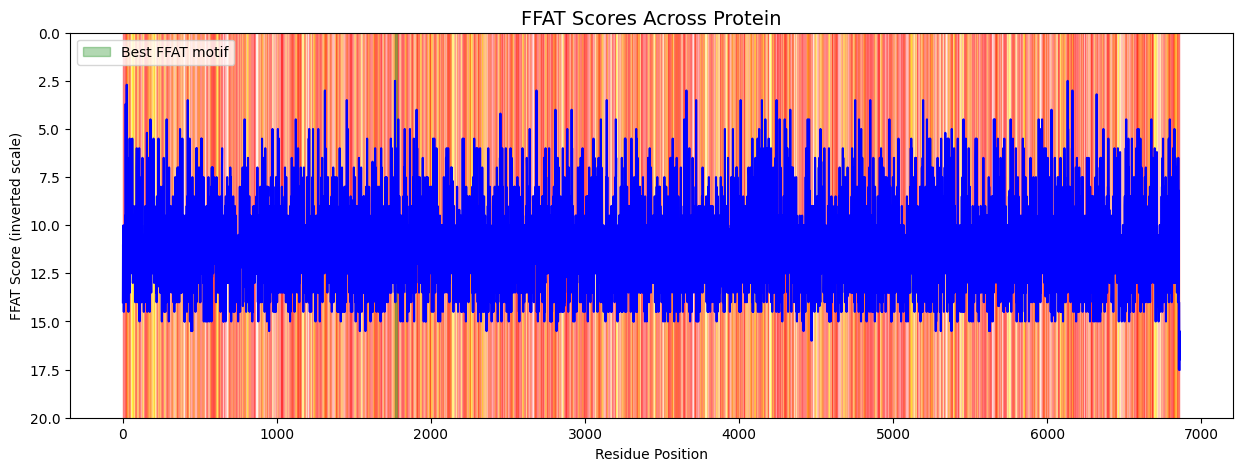

In [24]:
# ------------------------------
# Plotting
# ------------------------------
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(range(1, len(ffat_scores)+1), ffat_scores, color="blue", lw=1.5)
ax.set_title("FFAT Scores Across Protein", fontsize=14)
ax.set_xlabel("Residue Position")
ax.set_ylabel("FFAT Score (inverted scale)")
ax.set_ylim(bottom= 0, top=20)
ax.invert_yaxis()

# Red background for acidic residues, yellow for phosphorylatable residues
for i, res in enumerate(query_sequence, start=1):
    if res in ["D", "E"]:
        ax.axvspan(i-0.5, i+0.5, color="red", alpha=0.2)
    elif res in ["S", "T", "Y"]:
        ax.axvspan(i-0.5, i+0.5, color="yellow", alpha=0.2)

# Green highlight for best motif
ax.axvspan(best_idx, best_idx+17, color="green", alpha=0.3, label="Best FFAT motif")
ax.legend()

plt.show()

In [25]:
print(f"✅ Best FFAT motif found at {best_idx}–{best_idx+17}")
print(f"Motif sequence: {best_motif}")
print(f"Score: {best_score}")

✅ Best FFAT motif found at 1766–1783
Motif sequence: FKYYFKHEFLEAVENSE
Score: 2.5


In [26]:
# ------------------------------
# Print the 10 best (lowest) FFAT scores
# ------------------------------

# Create list of (index, score) pairs
score_positions = list(enumerate(ffat_scores))

# Sort by score (ascending = best first)
sorted_scores = sorted(score_positions, key=lambda x: x[1])

print("Top 10 best FFAT scores:\n")

for rank, (idx, score) in enumerate(sorted_scores[:10], start=1):

    # recover motif from padded sequence
    temp_seq = ['X']*8 + list(query_sequence) + ['X']*8
    motif = ''.join(temp_seq[idx:idx+17])

    print(f"{rank:2d}. Position: {idx:4d} | Score: {score:5.2f} | Motif: {motif}")

Top 10 best FFAT scores:

 1. Position: 1766 | Score:  2.50 | Motif: FKYYFKHEFLEAVENSE
 2. Position: 6131 | Score:  2.50 | Motif: KKLISEEEFDEAFEAVW
 3. Position:   25 | Score:  2.70 | Motif: EYWEIVDEFWESDYAGI
 4. Position: 1311 | Score:  3.00 | Motif: GEPLSESIFEDSDDESI
 5. Position: 2684 | Score:  3.00 | Motif: VSEEQKELFKEAVELLK
 6. Position: 3657 | Score:  3.00 | Motif: KVHKIVSDFFETLPHEA
 7. Position: 6162 | Score:  3.00 | Motif: LEEELYKIYDEAVEEID
 8. Position: 6319 | Score:  3.20 | Motif: MFEKIVEVFWEAYEERM
 9. Position:  421 | Score:  3.50 | Motif: SEVEVLEEFIESLKSIL
10. Position: 1453 | Score:  3.50 | Motif: FNTLDPDEFTEGLQEFI
